In [11]:
# ============================================
# Cell 0 — Setup
# ============================================

# Install external libraries (run once per Colab session).
# - kagglehub: to download the dataset directly from Kaggle
# - nltk: for text preprocessing (tokenization, stopwords, lemmatization, etc.)
!pip install -q kagglehub nltk

import os
import re
import string

import numpy as np
import pandas as pd

import kagglehub
import nltk

# Scikit-learn utilities for splitting data, feature extraction, and modelling
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Matplotlib for plotting confusion matrices
import matplotlib.pyplot as plt


In [12]:
# ============================================
# Cell 1 — Download NLTK resources
# ============================================

import nltk

# Tokenizers (punkt, punkt_tab): used by word_tokenize
nltk.download("punkt")
nltk.download("punkt_tab")

# Lemmatizer dictionary (WordNet) + additional multilingual wordnet data
nltk.download("wordnet")
nltk.download("omw-1.4")

# Stopword lists for removing common non-informative words
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
# ============================================
# Cell 2 — Download dataset and read the CSV
# Dataset: AI Generated Essays (Kaggle)
# ============================================

# 1) Kaggle dataset slug (can be changed if another dataset is used)
#    Here we use: "AI Generated Essays" dataset from Kaggle.
DATASET_SLUG = "denvermagtibay/ai-generated-essays-dataset"

# 2) Download the dataset folder (KaggleHub caches it after first run)
dataset_path = kagglehub.dataset_download(DATASET_SLUG)
print("Dataset downloaded to:", dataset_path)

# 3) List files in the downloaded folder to confirm CSV name
print("\nFiles in dataset folder:")
print(os.listdir(dataset_path))

# 4) Assume there is only ONE CSV file in this folder and select it
csv_files = [f for f in os.listdir(dataset_path) if f.lower().endswith(".csv")]
if not csv_files:
    raise FileNotFoundError("No CSV file found in the dataset folder!")

csv_name = csv_files[0]
csv_path = os.path.join(dataset_path, csv_name)
print("\nUsing CSV file:", csv_name)

# 5) Read the CSV into a DataFrame
df = pd.read_csv(csv_path)
print("Shape of raw DataFrame:", df.shape)
print("\nColumn names:", df.columns.tolist())

# Display first few rows to inspect the raw data
df.head()

Using Colab cache for faster access to the 'ai-generated-essays-dataset' dataset.
Dataset downloaded to: /kaggle/input/ai-generated-essays-dataset

Files in dataset folder:
['AI Generated Essays Dataset.csv']

Using CSV file: AI Generated Essays Dataset.csv
Shape of raw DataFrame: (1460, 2)

Column names: ['text', 'generated']


,text,generated
0,"Machine learning, a subset of artificial intel...",1
1,"A decision tree, a prominent machine learning ...",1
2,"Education, a cornerstone of societal progress,...",1
3,"Computers, the backbone of modern technology, ...",1
4,"Chess, a timeless game of strategy and intelle...",1


In [14]:
# ============================================
# Cell 3 — Select the text and label columns
# ============================================

# Column names based on df.columns from the previous cell.
# In this dataset:
#   "text"      → essay content
#   "generated" → label (0 = human-written, 1 = AI-generated)
TEXT_COL = "text"
LABEL_COL = "generated"

# Keep only the relevant columns and drop rows with missing values
df = df[[TEXT_COL, LABEL_COL]].dropna()

# Rename columns to standard names to simplify later code:
#   "text"  → input feature (raw essay)
#   "label" → target variable (0 or 1)
df = df.rename(columns={TEXT_COL: "text", LABEL_COL: "label"})

print("Data after selecting columns:", df.shape)
print("\nLabel distribution (0 = human, 1 = AI):")
print(df["label"].value_counts())

# Show example rows to verify the structure
df.head()

Data after selecting columns: (1460, 2)

Label distribution (0 = human, 1 = AI):
label
0    1375
1      85
Name: count, dtype: int64


,text,label
0,"Machine learning, a subset of artificial intel...",1
1,"A decision tree, a prominent machine learning ...",1
2,"Education, a cornerstone of societal progress,...",1
3,"Computers, the backbone of modern technology, ...",1
4,"Chess, a timeless game of strategy and intelle...",1


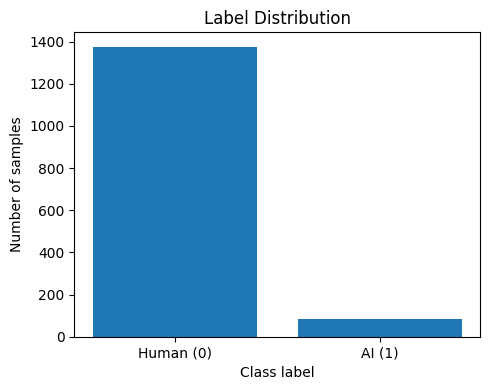

Label counts:
label
0    1375
1      85
Name: count, dtype: int64

Label distribution (%):
label
0    94.18
1     5.82
Name: count, dtype: float64


In [21]:
# ============================================
# Extra — Label distribution bar chart
#   (0 = Human-written, 1 = AI-generated)
# ============================================

label_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(["Human (0)", "AI (1)"], label_counts.values)
plt.title("Label Distribution")
plt.ylabel("Number of samples")
plt.xlabel("Class label")
plt.tight_layout()
plt.show()

print("Label counts:")
print(label_counts)
print("\nLabel distribution (%):")
print((label_counts / label_counts.sum() * 100).round(2))

In [15]:
# ============================================
# Cell 4 — Improved Text Cleaning + Lemmatization
#  - Lowercasing
#  - Remove URLs, HTML tags, punctuation, numbers
#  - Replace hyphens properly
#  - Tokenize
#  - Remove stopwords
#  - Lemmatize tokens
# ============================================

from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Load stopwords list once at the top of the notebook
stop_words = set(stopwords.words("english"))

# Initialize lemmatizer (reduces words to their base form)
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """
    Clean a single text string using several NLP preprocessing steps:
    - Convert to lowercase
    - Replace hyphens with spaces (e.g. "decision-making" → "decision making")
    - Remove URLs and HTML tags
    - Remove punctuation and digits
    - Normalize whitespace
    - Tokenize into individual words
    - Remove English stopwords
    - Lemmatize tokens (e.g. "running" → "run")

    Returns:
        A cleaned, lemmatized string ready for feature extraction.
    """

    # ---- Lowercase ----
    text = text.lower()

    # ---- Replace hyphens with space (fixes “decision-making”) ----
    text = text.replace("-", " ")

    # ---- Remove URLs & HTML ----
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)

    # ---- Remove punctuation ----
    text = text.translate(str.maketrans("", "", string.punctuation))

    # ---- Remove digits ----
    text = re.sub(r"\d+", " ", text)

    # ---- Normalize whitespace ----
    text = re.sub(r"\s+", " ", text).strip()

    # ---- Tokenize ----
    tokens = word_tokenize(text)

    # ---- Remove stopwords ----
    tokens = [tok for tok in tokens if tok not in stop_words]

    # ---- Lemmatize ----
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens]

    # Join tokens back to single cleaned string
    return " ".join(tokens)

# Apply improved cleaning to dataset (create a new column "clean_text")
df["clean_text"] = df["text"].astype(str).apply(clean_text)

print("Example of original vs cleaned+lemmatized:")
for i in range(3):
    print("\n--- Example", i, "---")
    print("Original :", df.iloc[i]["text"][:200])
    print("Clean+Lemma:", df.iloc[i]["clean_text"][:200])

Example of original vs cleaned+lemmatized:

--- Example 0 ---
Original : Machine learning, a subset of artificial intelligence, has rapidly emerged as a transformative force, revolutionizing industries and redefining the possibilities of technology. At its core, machine le
Clean+Lemma: machine learning subset artificial intelligence rapidly emerged transformative force revolutionizing industry redefining possibility technology core machine learning enables computer learn data make i

--- Example 1 ---
Original : A decision tree, a prominent machine learning algorithm, structures decision-making in a tree-like model. Nodes represent decisions, branches signify outcomes, and leaves denote final decisions or pre
Clean+Lemma: decision tree prominent machine learning algorithm structure decision making tree like model node represent decision branch signify outcome leaf denote final decision prediction algorithm evaluates in

--- Example 2 ---
Original : Education, a cornerstone of societal 

In [16]:
# ============================================
# Cell 5 — Split into train and test sets
#   (3.2.2: Data preprocessing → train/test split)
# ============================================

# Features: cleaned text (preprocessed essays)
X = df["clean_text"].values

# Target: label (0 = human-written, 1 = AI-generated)
y = df["label"].values

# Stratified split keeps the same proportion of classes in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% of data used as test set
    stratify=y,           # preserve label distribution in train and test
    random_state=42       # for reproducibility
)

print("Train size:", len(X_train))
print("Test size :", len(X_test))

Train size: 1168
Test size : 292


In [17]:
# ============================================
# Cell 6 — Bag-of-Words using CountVectorizer
#   (Simple BoW representation for comparison)
# ============================================

from sklearn.feature_extraction.text import CountVectorizer

# Plain Bag-of-Words (word counts) representation.
# Each document is represented as a sparse vector of token counts.
count_vectorizer = CountVectorizer(
    max_features=50000,    # limit vocabulary size for efficiency
    stop_words='english'   # remove common English stop words
)

# Learn vocabulary from training data and transform training set
X_train_count = count_vectorizer.fit_transform(X_train)

# Transform test data using the same vocabulary (no refitting)
X_test_count = count_vectorizer.transform(X_test)

print("Count BoW shape for training data:", X_train_count.shape)
print("Count BoW shape for test data    :", X_test_count.shape)

Count BoW shape for training data: (1168, 14607)
Count BoW shape for test data    : (292, 14607)


In [18]:
# ============================================
# Cell 7 — Naive Bayes on CountVectorizer features
#   (Baseline BoW model)
# ============================================

# Multinomial Naive Bayes is a standard choice for text classification
# with count-based features (Bag-of-Words).
nb_model_count = MultinomialNB(alpha=0.1)

# Train Naive Bayes on plain BoW counts (training set only)
nb_model_count.fit(X_train_count, y_train)

# Predict on the held-out test set (unseen data)
y_pred_nb_count = nb_model_count.predict(X_test_count)

# Evaluate with accuracy and a detailed classification report
nb_count_accuracy = accuracy_score(y_test, y_pred_nb_count)
print(f"Naive Bayes (Count BoW) Accuracy: {nb_count_accuracy:.4f}\n")

print("Naive Bayes (Count BoW) classification report:")
print(classification_report(y_test, y_pred_nb_count))

Naive Bayes (Count BoW) Accuracy: 0.9932

Naive Bayes (Count BoW) classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       275
           1       1.00      0.88      0.94        17

    accuracy                           0.99       292
   macro avg       1.00      0.94      0.97       292
weighted avg       0.99      0.99      0.99       292



In [19]:
# ============================================
# Cell 8 — Logistic Regression on CountVectorizer features
#   (Baseline BoW logistic model)
# ============================================

# Logistic Regression is a strong linear baseline for text classification.
# Here we use:
# - saga solver: works well with large sparse datasets
# - class_weight='balanced': compensates for any class imbalance
# - max_iter increased to ensure convergence.
log_reg_model_count = LogisticRegression(
    max_iter=2000,
    C=10.0,
    solver='saga',
    penalty='l2',
    class_weight='balanced',
    n_jobs=-1
)

# Train Logistic Regression on BoW counts (training set only)
log_reg_model_count.fit(X_train_count, y_train)

# Predict on the held-out test set (unseen data)
y_pred_lr_count = log_reg_model_count.predict(X_test_count)

# Evaluate with accuracy and a detailed classification report
lr_count_accuracy = accuracy_score(y_test, y_pred_lr_count)
print(f"Logistic Regression (Count BoW) Accuracy: {lr_count_accuracy:.4f}\n")

print("Logistic Regression (Count BoW) classification report:")
print(classification_report(y_test, y_pred_lr_count))

Logistic Regression (Count BoW) Accuracy: 0.9932

Logistic Regression (Count BoW) classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       275
           1       1.00      0.88      0.94        17

    accuracy                           0.99       292
   macro avg       1.00      0.94      0.97       292
weighted avg       0.99      0.99      0.99       292



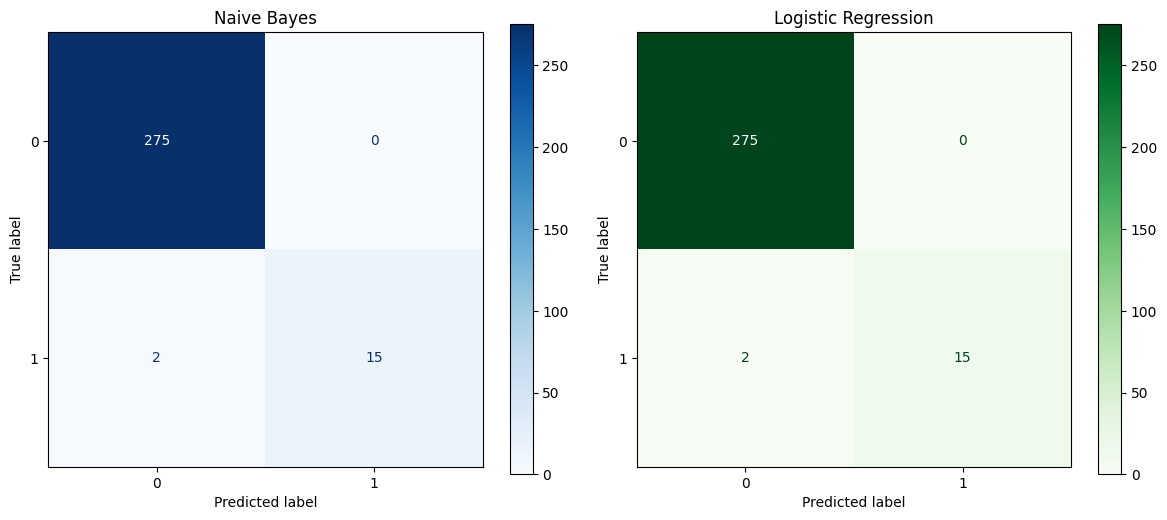

In [20]:
# ============================================
# Cell 9 — Plot confusion matrices for both models
# ============================================

# Visual comparison of model errors using confusion matrices:
# Rows = true labels, Columns = predicted labels.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Naive Bayes confusion matrix on test data
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb_count,
    ax=axes[0],
    cmap="Blues"
)
axes[0].set_title("Naive Bayes")

# Logistic Regression confusion matrix on test data
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr_count,
    ax=axes[1],
    cmap="Greens"
)
axes[1].set_title("Logistic Regression")

plt.tight_layout()
plt.show()